In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from inversion import BBCH

In [3]:
pheno = BBCH(workspace_dir='../assets')
df = pheno.run()
print(df.shape)
df.head()

Found RISMA_CSV folder: RISMA_CSV_files
RISMA_CSV folder already exists: ../assets/inputs/RISMA_CSV_files
	Processing file: RISMA_MB1_2010_to_2024.csv
	Processing file: RISMA_MB2_2010_to_2024.csv
	Processing file: RISMA_MB3_2010_to_2024.csv
	Processing file: RISMA_MB4_2010_to_2024.csv
	Processing file: RISMA_MB5_2010_to_2024.csv
	Processing file: RISMA_MB6_2010_to_2024.csv
	Processing file: RISMA_MB7_2010_to_2024.csv
	Processing file: RISMA_MB8_2010_to_2024.csv
	Processing file: RISMA_MB9_2010_to_2024.csv
	Processing file: RISMA_MB10_2010_to_2024.csv
	Processing file: RISMA_MB11_2010_to_2024.csv
	Processing file: RISMA_MB12_2010_to_2024.csv
	Processing file: RISMA_MB13_2010_to_2024.csv
Found GEE folder: S1_CSV_files
S1_CSV folder already exists: ../assets/inputs/S1_CSV_files
	Processing file: S1_Backscatter_RISMA_MB1_2010_to_2024_buffer20m.csv
	Processing file: S1_Backscatter_RISMA_MB2_2010_to_2024_buffer20m.csv
	Processing file: S1_Backscatter_RISMA_MB3_2010_to_2024_buffer20m.csv
	Pro

,date,station,depth,op,mean_sst,mean_airt,SSM,SST,year,doy,...,VH,VV,angle,lc,BASE_TEMP,cum_GDD_air,cum_GDD_soil,cum_GDD,BBCH,cum_SSM
0,2015-04-25,MB1,0 to 5 cm,0,10.185,7.835,0.130000,14.977778,2015,115,...,-20.0,-13.0,40.0,146,5,2.835,5.185,4.0100,0.0,0.130000
1,2015-04-25,MB10,0 to 5 cm,0,7.500,7.840,0.432222,12.633333,2015,115,...,-27.0,-20.0,43.0,146,5,5.675,7.685,6.6800,0.0,0.562222
2,2015-04-25,MB11,0 to 5 cm,0,8.635,8.380,0.272222,12.577778,2015,115,...,-22.0,-14.0,42.0,158,10,5.675,7.685,6.6800,0.0,0.834444
3,2015-04-25,MB12,0 to 5 cm,0,5.350,8.015,0.310000,14.266667,2015,115,...,-22.0,-12.0,42.0,146,5,8.690,8.035,8.3625,0.0,1.144444
4,2015-04-25,MB2,0 to 5 cm,0,13.265,8.305,0.340000,15.955556,2015,115,...,-19.0,-9.0,40.0,146,5,11.995,16.300,14.1475,0.0,1.484444


In [24]:
df.columns

Index(['date', 'station', 'depth', 'op', 'mean_sst', 'mean_airt', 'SSM', 'SST',
       'year', 'doy', 'Station', 'Depth (cm)', 'bulk', 'Sand', 'Silt', 'Clay',
       'Classification', 'index', 'VH', 'VV', 'angle', 'lc', 'BASE_TEMP',
       'cum_GDD_air', 'cum_GDD_soil', 'cum_GDD', 'BBCH', 'cum_SSM', 'year_int',
       'year_str'],
      dtype='object')

In [4]:
# save the DataFrame to a CSV file
df.to_csv('../assets/outputs/bbch_df.csv', index=False)

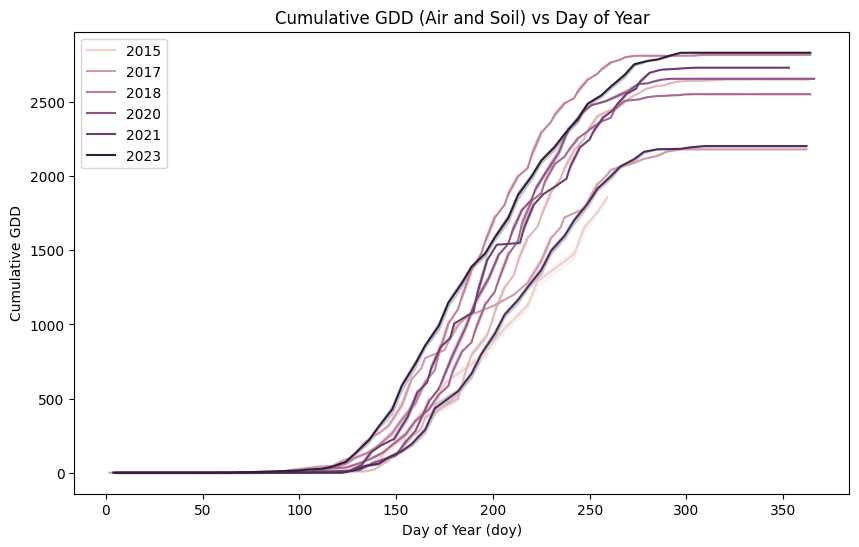

In [4]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='doy', y='cum_GDD', data=df, hue='year')
plt.xlabel('Day of Year (doy)')
plt.ylabel('Cumulative GDD')
plt.title('Cumulative GDD (Air and Soil) vs Day of Year')
plt.legend()
plt.show()

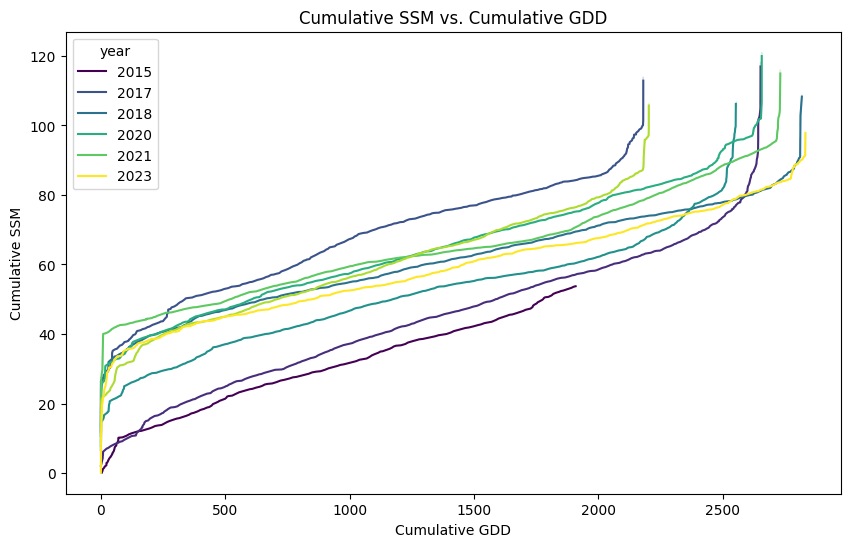

In [6]:
# Create the line plot using seaborn
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.lineplot(x='cum_GDD', y='cum_SSM', hue='year', data=df, palette='viridis')  # Use 'year' for color
plt.xlabel('Cumulative GDD')
plt.ylabel('Cumulative SSM')
plt.title('Cumulative SSM vs. Cumulative GDD')
plt.show()

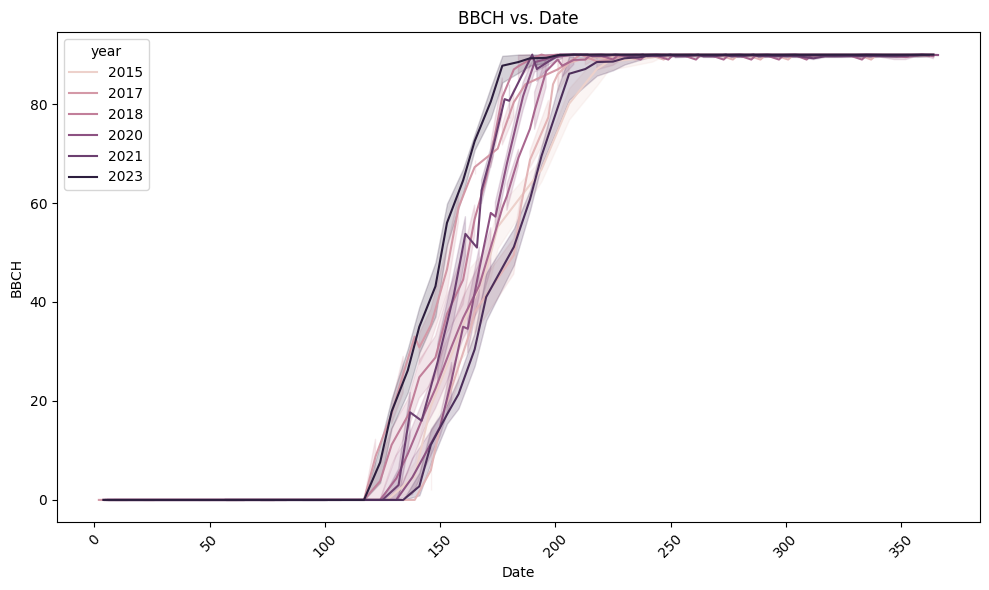

In [7]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='doy', y='BBCH', data=df, hue='year')
plt.xlabel('Date')
plt.ylabel('BBCH')
plt.title('BBCH vs. Date')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

In [22]:
df['year'] = df['date'].dt.year.astype(str)  # Extract year from date
df['doy'] = df['date'].dt.dayofyear.astype(int)  # Extract day of year from date

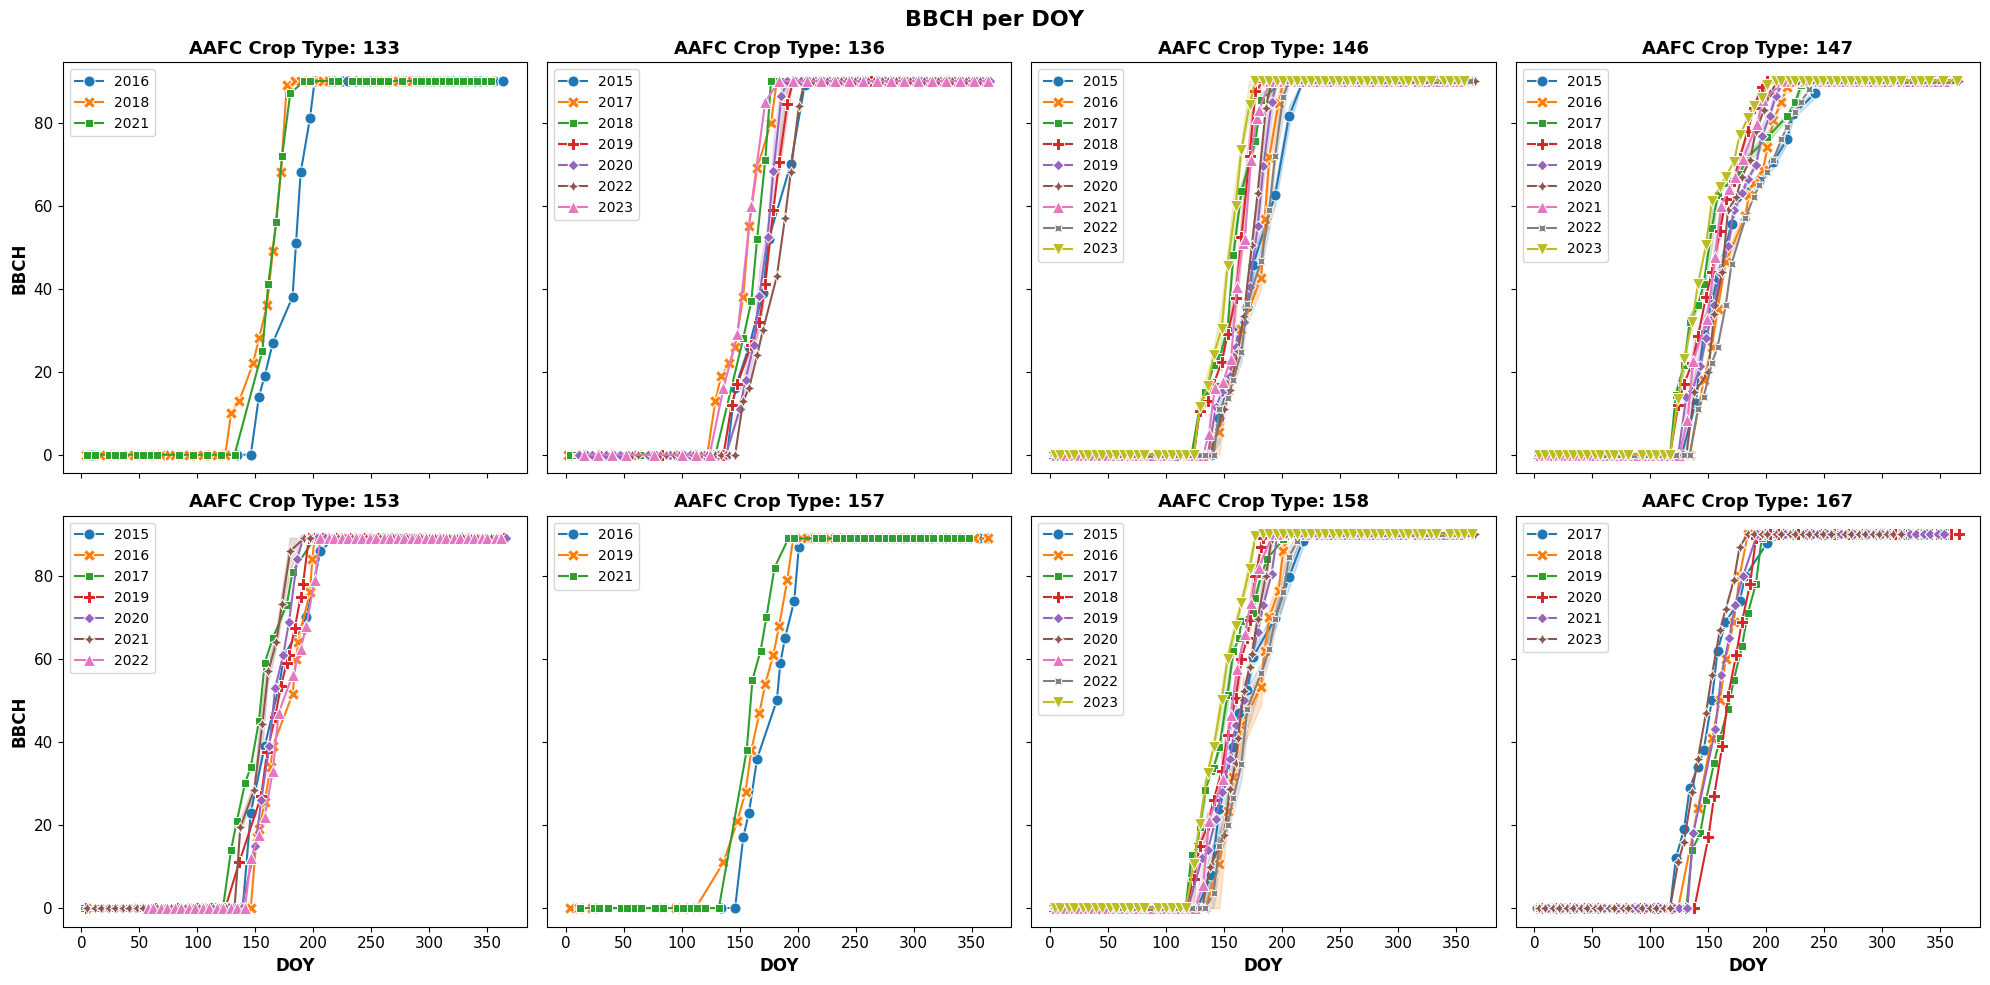

In [26]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
fig.suptitle('BBCH per DOY', fontsize=16, fontweight='bold')

# Get unique crop types (all 8 crop types)
crop_types = df['lc'].unique()  # Replace 'lc' with your crop type column name
crop_types = sorted(crop_types)[:8]  # Take all 8 crop types

# Plot crop height for each crop type
for i, crop in enumerate(crop_types):
    row = i // 4  # Determine row (0 or 1)
    col = i % 4   # Determine column (0, 1, 2, or 3)
    
    crop_data = df[df['lc'] == crop]  # Replace 'lc' with your crop type column
    
    # Plot crop height vs DOY with year as hue and crop type as style
    sns.lineplot(x='doy', y='BBCH', data=crop_data, 
                 hue='year', 
                 style='year', 
                 markers=True, dashes=False, markersize=8, ax=axes[row, col])
    
    axes[row, col].set_title(f'AAFC Crop Type: {crop}', fontsize=13, fontweight='bold')
    axes[row, col].set_xlabel('DOY', fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel('BBCH', fontsize=12, fontweight='bold')
    axes[row, col].tick_params(labelsize=11)
    
    # Adjust legend for each subplot
    legend = axes[row, col].get_legend()
    if legend:
        axes[row, col].legend(ncol=1, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

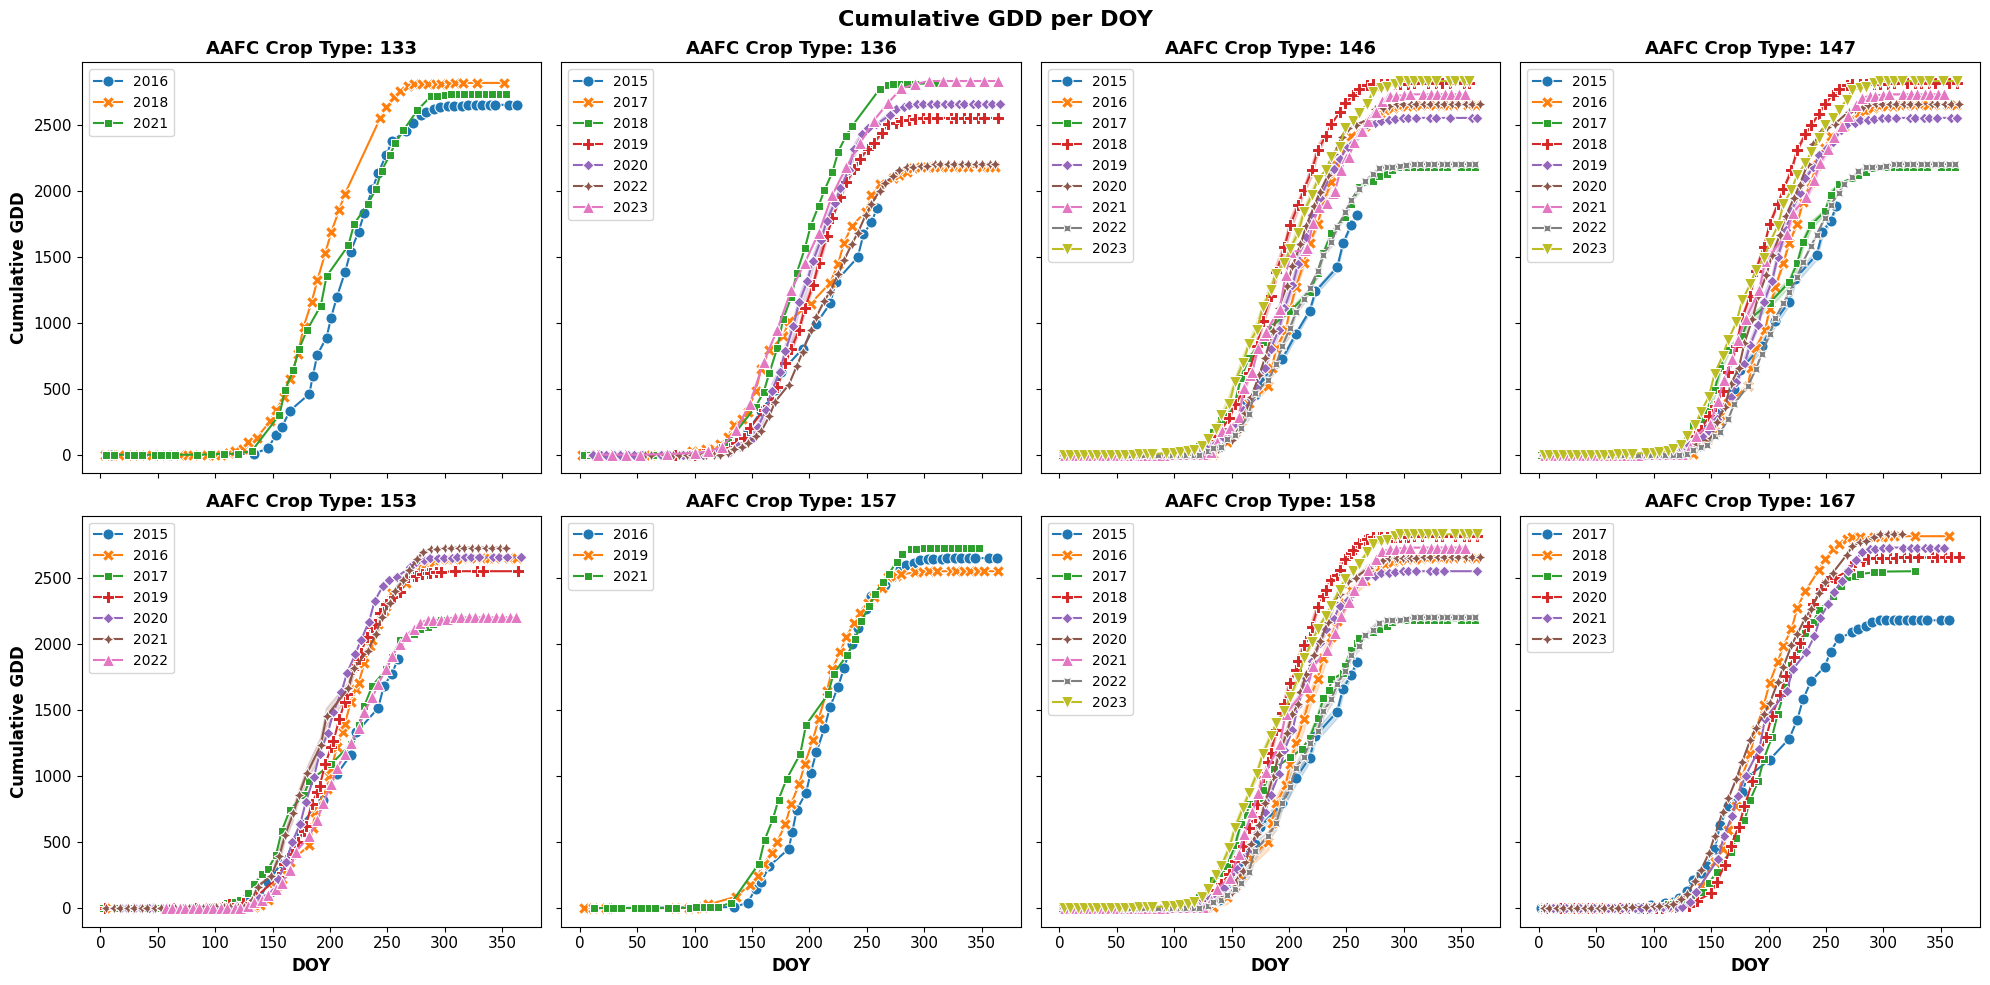

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
fig.suptitle('Cumulative GDD per DOY', fontsize=16, fontweight='bold')

# Get unique crop types (all 8 crop types)
crop_types = df['lc'].unique()  # Replace 'lc' with your crop type column name
crop_types = sorted(crop_types)[:8]  # Take all 8 crop types

# Plot crop height for each crop type
for i, crop in enumerate(crop_types):
    row = i // 4  # Determine row (0 or 1)
    col = i % 4   # Determine column (0, 1, 2, or 3)
    
    crop_data = df[df['lc'] == crop]  # Replace 'lc' with your crop type column
    
    # Plot crop height vs DOY with year as hue and crop type as style
    sns.lineplot(x='doy', y='cum_GDD', data=crop_data, 
                 hue='year', 
                 style='year', 
                 markers=True, dashes=False, markersize=8, ax=axes[row, col])
    
    axes[row, col].set_title(f'AAFC Crop Type: {crop}', fontsize=13, fontweight='bold')
    axes[row, col].set_xlabel('DOY', fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel('Cumulative GDD', fontsize=12, fontweight='bold')
    axes[row, col].tick_params(labelsize=11)
    
    # Adjust legend for each subplot
    legend = axes[row, col].get_legend()
    if legend:
        axes[row, col].legend(ncol=1, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

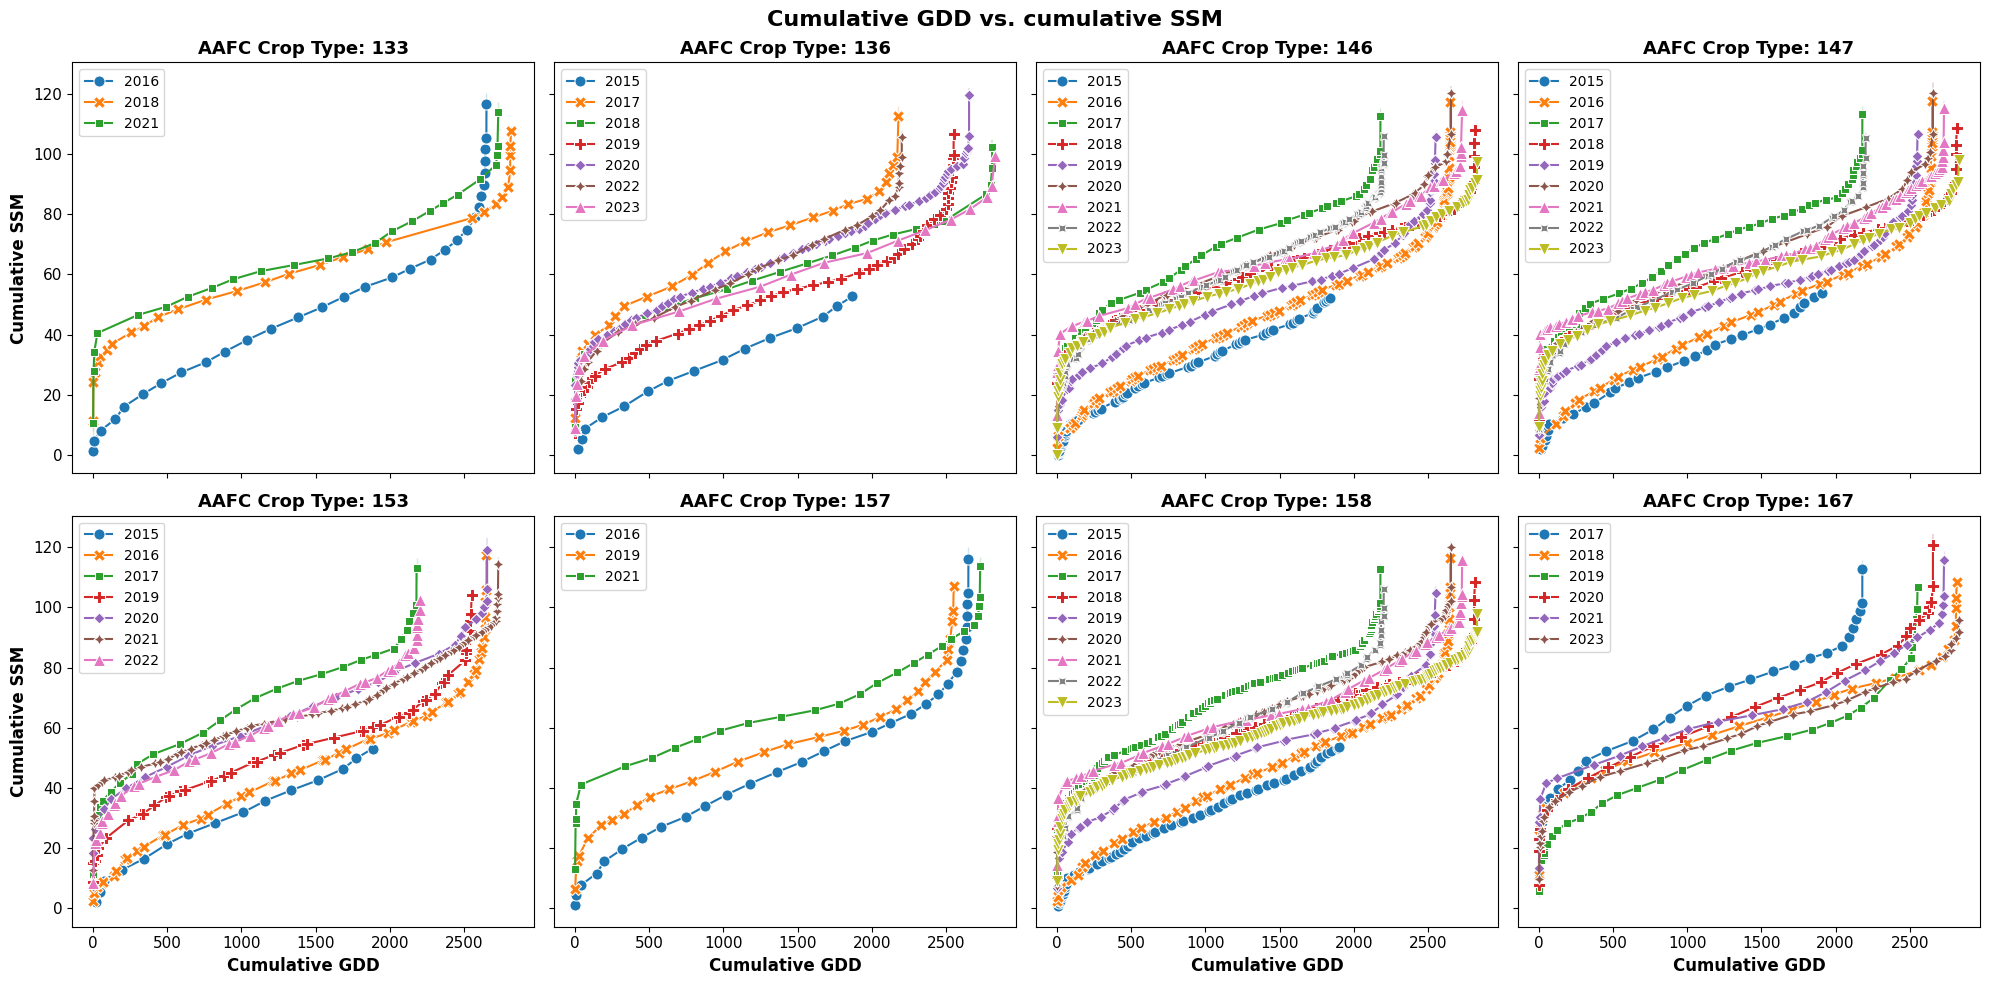

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
fig.suptitle('Cumulative GDD vs. cumulative SSM', fontsize=16, fontweight='bold')

# Get unique crop types (all 8 crop types)
crop_types = df['lc'].unique()  # Replace 'lc' with your crop type column name
crop_types = sorted(crop_types)[:8]  # Take all 8 crop types

# Plot crop height for each crop type
for i, crop in enumerate(crop_types):
    row = i // 4  # Determine row (0 or 1)
    col = i % 4   # Determine column (0, 1, 2, or 3)
    
    crop_data = df[df['lc'] == crop]  # Replace 'lc' with your crop type column
    
    # Plot crop height vs DOY with year as hue and crop type as style
    sns.lineplot(x='cum_GDD', y='cum_SSM', data=crop_data, 
                 hue='year', 
                 style='year', 
                 markers=True, dashes=False, markersize=8, ax=axes[row, col])
    
    axes[row, col].set_title(f'AAFC Crop Type: {crop}', fontsize=13, fontweight='bold')
    axes[row, col].set_xlabel('Cumulative GDD', fontsize=12, fontweight='bold')
    axes[row, col].set_ylabel('Cumulative SSM', fontsize=12, fontweight='bold')
    axes[row, col].tick_params(labelsize=11)
    
    # Adjust legend for each subplot
    legend = axes[row, col].get_legend()
    if legend:
        axes[row, col].legend(ncol=1, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()